# Lesson 3: Scores → probabilities → loss

**Why:** in Lesson 2 the model predicted a **number**. A GPT has to **choose**: "which of the 85 characters comes next?" This lesson covers the three steps that make choosing possible, and they're the final steps of every GPT:

```
85 raw scores      ──softmax──►   85 probabilities   ──►  pick one (to write text)
  ("logits")                       (all add up to 1)  ──►  measure how wrong (to learn)
```

To keep everything visible, we pretend our alphabet has only **4 characters**: `a`, `e`, `t` and space.

## 1. Softmax: turning scores into probabilities

The model outputs raw **scores** (called **logits**). They can be any number, even negative. **Softmax** turns them into probabilities:

$$p_i = \frac{e^{\,\text{score}_i}}{\text{sum of } e^{\,\text{score}} \text{ over all characters}}$$

- $e^{\text{score}}$ makes every number positive, and **exaggerates differences**: a slightly higher score gets a much bigger share.
- Dividing by the total makes them **add up to 1**.

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)

vocab = ["a", "e", "t", "␣"]                   # ␣ = space
logits = torch.tensor([2.0, 1.0, 0.1, -1.0])  # the model's raw scores

exps = logits.exp()
probs = exps / exps.sum()                      # softmax by hand

for ch, s, p in zip(vocab, logits, probs):
    print(f"'{ch}'  score={s.item():5.1f}  ->  probability={p.item():.3f}")
print("total:", probs.sum().item())
print("same as PyTorch's softmax:", torch.allclose(probs, F.softmax(logits, dim=-1)))

'a'  score=  2.0  ->  probability=0.638
'e'  score=  1.0  ->  probability=0.235
't'  score=  0.1  ->  probability=0.095
'␣'  score= -1.0  ->  probability=0.032
total: 0.9999998807907104
same as PyTorch's softmax: True


## 2. Cross-entropy: how wrong was the guess?

Say the correct next character was **`e`**. The loss only looks at **the probability the model gave to the right answer**:

$$\text{loss} = -\ln(p_{\text{correct}})$$

| probability given to the right answer | loss |
|---|---|
| 1.0 (completely sure, and right) | 0 |
| 0.5 | 0.69 |
| 0.1 | 2.30 |
| 0.01 | 4.61 |

Confident and wrong is punished hardest. `F.cross_entropy` does softmax + this formula in one go, straight from the raw scores.

In [2]:
target = torch.tensor([1])                      # the right answer is index 1 = 'e'

by_hand = -torch.log(probs[1])
pytorch = F.cross_entropy(logits.unsqueeze(0), target)   # wants (examples, vocab) scores

print(f"model gave 'e' probability {probs[1].item():.3f}")
print(f"loss by hand: {by_hand.item():.4f}")
print(f"loss PyTorch: {pytorch.item():.4f}")

model gave 'e' probability 0.235
loss by hand: 1.4493
loss PyTorch: 1.4493


## 3. The "knows nothing" starting point

**Predict:** a brand-new model that knows nothing gives **all 85 characters the same score**, so each gets probability 1/85. What will its loss be? (Hint: −ln(1/85). A calculator helps, or just guess whether it's closer to 1, 4 or 10.)

This number matters: it's the loss we **expect to see at step 0** when we start training on Tesla. If we see something very different, there's a bug.

In [3]:
V = 85
knows_nothing = torch.zeros(1, V)               # all 85 scores equal
loss = F.cross_entropy(knows_nothing, torch.tensor([0]))

print(f"loss of a know-nothing model: {loss.item():.4f}")
print(f"ln(85) =                      {math.log(V):.4f}")

loss of a know-nothing model: 4.4427
ln(85) =                      4.4427


## 4. `nn.Embedding`: a lookup table

The model needs numbers for each character. **`nn.Embedding(4, 3)`** is a table with **one row per character** and 3 learnable numbers in each row. Give it character numbers (indices) and it hands back those rows. That's all it does.

In Lesson 6 our first model is exactly this: a table of 85 rows × 85 scores. "After this character, here are the scores for each possible next character."

In [4]:
emb = nn.Embedding(4, 3)          # 4 characters, 3 numbers each
print("the table (4 rows x 3):")
print(emb.weight.data)

idx = torch.tensor([1, 1, 3])     # look up 'e', 'e', '␣'
rows = emb(idx)                   # (3, 3)
print("\nlooked up rows for e, e, ␣:")
print(rows.data)
print("row 0 is the same as table row 1:", torch.equal(rows[0], emb.weight[1]))

the table (4 rows x 3):
tensor([[ 1.5410, -0.2934, -2.1788],
        [ 0.5684, -1.0845, -1.3986],
        [ 0.4033,  0.8380, -0.7193],
        [-0.4033, -0.5966,  0.1820]])

looked up rows for e, e, ␣:
tensor([[ 0.5684, -1.0845, -1.3986],
        [ 0.5684, -1.0845, -1.3986],
        [-0.4033, -0.5966,  0.1820]])
row 0 is the same as table row 1: True


## 5. Sampling: picking a character

To write text, the model **rolls a weighted dice**: each character's chance of being picked equals its probability. `torch.multinomial` does this.

Why not always pick the top one? Because then the model writes the same thing every time and gets stuck in loops. Sampling gives it variety.

first 40 picks: aaaaaaeeaeaaaaaeeaeaaaataaeaaaeaaaea␣tea


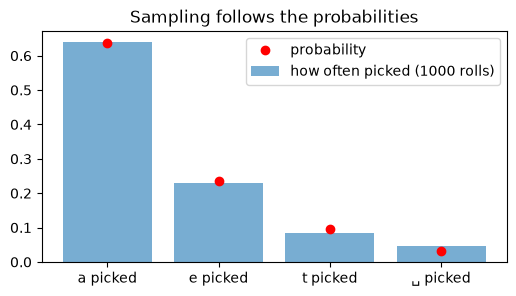

In [5]:
picks = torch.multinomial(probs, num_samples=1000, replacement=True)

print("first 40 picks:", "".join(vocab[i] for i in picks[:40]))

counts = torch.bincount(picks, minlength=4) / 1000
plt.figure(figsize=(6, 3))
plt.bar([c + " picked" for c in vocab], counts, alpha=0.6, label="how often picked (1000 rolls)")
plt.plot(range(4), probs, "ro", label="probability")
plt.legend(); plt.title("Sampling follows the probabilities"); plt.show()

## 6. Final check

In [6]:
assert torch.allclose(probs.sum(), torch.tensor(1.0))
assert abs(loss.item() - math.log(85)) < 1e-4
assert rows.shape == (3, 3)
print("Lesson 3 complete. Foundations done!")

Lesson 3 complete. Foundations done!


## Wrap-up question

If the model gives the correct next character a probability of **0.5**, what's the loss? Is that better or worse than the know-nothing model from section 3?